In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [5]:
X_train = np.load("../data/processed/X_train.npy")
X_test = np.load("../data/processed/X_test.npy")

y_train = np.load("../data/processed/y_train.npy")
y_test = np.load("../data/processed/y_test.npy")

In [6]:
# create sequence 

TIME_STEPS = 24

def create_sequences(X, y, time_steps):

    Xs = []
    ys = []

    for i in range(len(X) - time_steps):

        Xs.append(X[i:(i + time_steps)])

        ys.append(y[i + time_steps])

    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(
    X_train,
    y_train,
    TIME_STEPS
)

X_test_seq, y_test_seq = create_sequences(
    X_test,
    y_test,
    TIME_STEPS
)

In [11]:
# lstm model
model = Sequential()

model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]
        )
    )
)

model.add(Dropout(0.2))

model.add(LSTM(64))

model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))

model.add(Dense(1))

c:\Users\ajita\OneDrive\Desktop\Solar Power Prediction\solar_power_prediction\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
# compile model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [13]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - loss: 0.0229 - mae: 0.1019 - val_loss: 0.0147 - val_mae: 0.0710
Epoch 2/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - loss: 0.0119 - mae: 0.0677 - val_loss: 0.0167 - val_mae: 0.0702
Epoch 3/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 0.0111 - mae: 0.0620 - val_loss: 0.0152 - val_mae: 0.0628
Epoch 4/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - loss: 0.0100 - mae: 0.0576 - val_loss: 0.0140 - val_mae: 0.0548
Epoch 5/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - loss: 0.0093 - mae: 0.0540 - val_loss: 0.0149 - val_mae: 0.0587
Epoch 6/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - loss: 0.0090 - mae: 0.0528 - val_loss: 0.0147 - val_mae: 0.0648
Epoch 7/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - loss: 0.0088 - mae: 0.0511 - val_loss: 0.0125 - val_mae: 0.0548
Epoch 8/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 0.0081 - mae: 0.0486 - val_loss: 0.0161 - val_mae: 0.0606
Epoch 9/50
336/336 ━━━━━━━━━━━━━━━━━━━━ 

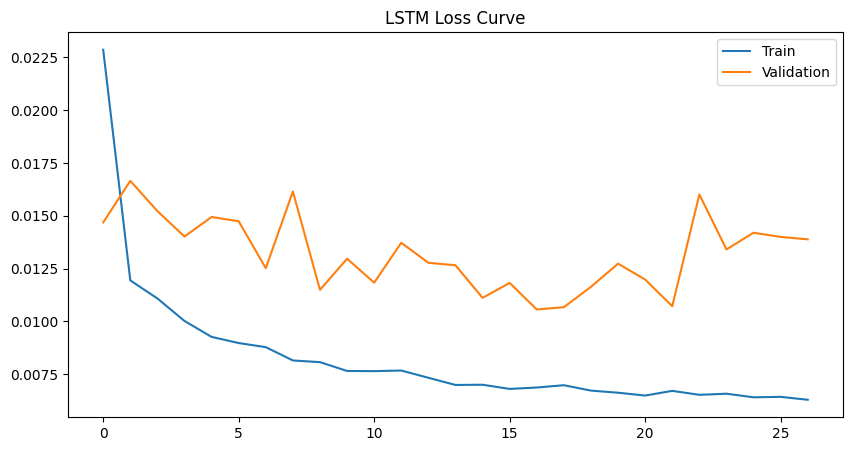

In [14]:
# plot loss
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.legend(['Train', 'Validation'])

plt.title("LSTM Loss Curve")

plt.show()

In [15]:
#prediction
y_pred = model.predict(X_test_seq)

# metrics
mae = mean_absolute_error(
    y_test_seq,
    y_pred
)

rmse = math.sqrt(
    mean_squared_error(
        y_test_seq,
        y_pred
    )
)

r2 = r2_score(
    y_test_seq,
    y_pred
)

print("MAE :", mae)

print("RMSE:", rmse)

print("R2 :", r2)


105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
MAE : 0.06263387989516381
RMSE: 0.11593775956196845
R2 : 0.8402019578484021


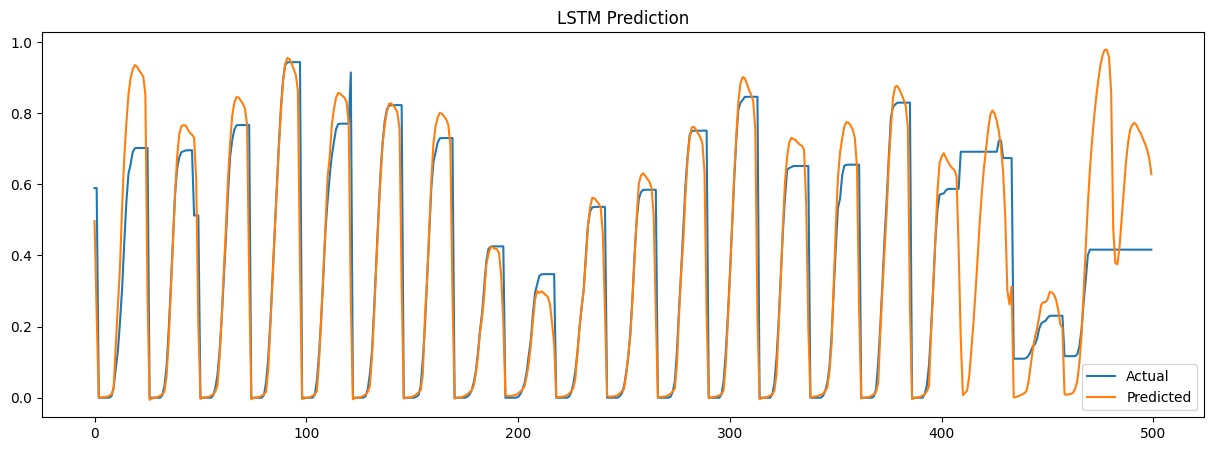

In [16]:
# prediction graph
plt.figure(figsize=(15,5))

plt.plot(y_test_seq[:500], label='Actual')

plt.plot(y_pred[:500], label='Predicted')

plt.legend()

plt.title("LSTM Prediction")

plt.show()